# HW #6 — Conditional GAN (cGAN) for MNIST Digit Translation

**Course:** Deep Learning (DL 525.733-8VL)
**Due Date:** April 2, 2026
**Samih Amer**

---

## Assignment Overview

This notebook implements a **conditional GAN (cGAN)** based on the **pix2pix** framework to perform
image-to-image translation on MNIST digits. Given an image of an even digit, the generator learns to
produce the corresponding odd digit:

| Input (Even) | Output (Odd) |
|:---:|:---:|
| 0 | 1 |
| 2 | 3 |
| 4 | 5 |
| 6 | 7 |
| 8 | 9 |

### Architecture

The cGAN follows the pix2pix paradigm from Isola et al.:

- **Generator (G):** A **U-Net** encoder-decoder with skip connections. The encoder compresses the
  input image into a latent representation, and the decoder reconstructs the target digit. Skip
  connections preserve spatial detail from the encoder, enabling sharper outputs.

- **Discriminator (D):** A **PatchGAN** classifier that evaluates overlapping local patches rather
  than the full image. This pushes the generator to produce realistic high-frequency details.

- **Training objective:**
  - *Adversarial loss:* Binary cross-entropy — the generator tries to fool the discriminator.
  - *L1 reconstruction loss:* Encourages pixel-level similarity to the ground-truth target.
  - Combined: $\mathcal{L}_G = \mathcal{L}_{GAN}(G, D) + \lambda \cdot \mathcal{L}_{L1}(G)$, with $\lambda = 100$.

### Reference

[1] Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017). *"Image-to-Image Translation with
Conditional Adversarial Networks."* CVPR 2017. Berkeley AI Research (BAIR) Laboratory, UC Berkeley.

## 1. Imports and Setup

We use **PyTorch** for model definition and training, **NumPy** for data manipulation, and
**Matplotlib** for visualization. The MNIST data is loaded directly from the raw IDX binary files
stored in the HW4 archive folder using Python's `struct` module.

In [1]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- Inline plotting and style ---
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# --- Reproducibility ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Device configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load MNIST Data

The MNIST dataset is stored in the **IDX binary format**. Each image file begins with a 16-byte
header (magic number, count, rows, cols) followed by raw pixel bytes. Each label file begins with
an 8-byte header (magic number, count) followed by one byte per label.

We load training images (60,000) and test images (10,000) from the archive in `../HW4 Autoencoder/archive/`.

In [2]:
def load_mnist_images(filepath):
    """Load MNIST images from an IDX file.

    The IDX format stores a 16-byte big-endian header:
        [magic (4B)] [num_images (4B)] [rows (4B)] [cols (4B)]
    followed by (num_images * rows * cols) raw pixel bytes (uint8).
    """
    with open(filepath, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num_images, rows, cols)
    return images


def load_mnist_labels(filepath):
    """Load MNIST labels from an IDX file.

    The IDX format stores an 8-byte big-endian header:
        [magic (4B)] [num_labels (4B)]
    followed by num_labels bytes, one label per image.
    """
    with open(filepath, 'rb') as f:
        magic, num_labels = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


# --- Path to MNIST archive from HW4 ---
DATA_DIR = os.path.join('..', 'HW4 Autoencoder', 'archive')

# Load training data (60,000 images)
train_images = load_mnist_images(
    os.path.join(DATA_DIR, 'train-images-idx3-ubyte', 'train-images-idx3-ubyte'))
train_labels = load_mnist_labels(
    os.path.join(DATA_DIR, 'train-labels-idx1-ubyte', 'train-labels-idx1-ubyte'))

# Load test data (10,000 images)
test_images = load_mnist_images(
    os.path.join(DATA_DIR, 't10k-images-idx3-ubyte', 't10k-images-idx3-ubyte'))
test_labels = load_mnist_labels(
    os.path.join(DATA_DIR, 't10k-labels-idx1-ubyte', 't10k-labels-idx1-ubyte'))

print(f"Training set: {train_images.shape[0]:,} images, shape {train_images.shape[1:]}")
print(f"Test set:     {test_images.shape[0]:,} images, shape {test_images.shape[1:]}")
print(f"Label range:  {train_labels.min()} - {train_labels.max()}")

# Show per-digit counts
for d in range(10):
    n_train = (train_labels == d).sum()
    n_test  = (test_labels == d).sum()
    print(f"  Digit {d}: {n_train:,} train, {n_test:,} test")

Training set: 60,000 images, shape (28, 28)
Test set:     10,000 images, shape (28, 28)
Label range:  0 - 9
  Digit 0: 5,923 train, 980 test
  Digit 1: 6,742 train, 1,135 test
  Digit 2: 5,958 train, 1,032 test
  Digit 3: 6,131 train, 1,010 test
  Digit 4: 5,842 train, 982 test
  Digit 5: 5,421 train, 892 test
  Digit 6: 5,918 train, 958 test
  Digit 7: 6,265 train, 1,028 test
  Digit 8: 5,851 train, 974 test
  Digit 9: 5,949 train, 1,009 test


## 3. Create Paired Dataset for cGAN Training

The pix2pix cGAN requires **paired training data** — each input image must be paired with a
corresponding target image. For our even-to-odd digit translation task:

1. **Group images by digit class** — separate all 0s, 1s, 2s, etc.
2. **Create random pairs** — for each mapping (e.g., 0 $\to$ 1), randomly pair an image of the
   source digit with an image of the target digit.
3. **Preprocess** — pad 28$\times$28 images to 32$\times$32 (2-pixel zero-pad on each side) for
   clean powers-of-2 convolution arithmetic, and normalize pixel values to $[-1, 1]$ to match the
   generator's Tanh output.

| Preprocessing Step | Details |
|---|---|
| Padding | 28$\times$28 $\to$ 32$\times$32 (2px each side) |
| Normalization | $[0, 255] \to [-1, 1]$ |
| Pairing | Random 1:1 matching within each digit pair |

In [3]:
# --- Digit pair mappings (even -> odd) ---
DIGIT_PAIRS = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]
IMG_SIZE     = 32   # Pad 28x28 -> 32x32 for clean conv arithmetic
BATCH_SIZE   = 64


class MNISTDigitPairDataset(Dataset):
    """Custom Dataset that creates (input, target) pairs for cGAN training.

    For each digit mapping (e.g., 0 -> 1), source-digit images are randomly
    paired with target-digit images.  Both images are padded to 32x32 and
    normalised to [-1, 1].

    Attributes:
        data : list of (src_img, tgt_img, src_digit, tgt_digit) tuples
    """

    def __init__(self, images, labels, digit_pairs=DIGIT_PAIRS, seed=42):
        super().__init__()
        self.data = []
        rng = np.random.RandomState(seed)

        for src_digit, tgt_digit in digit_pairs:
            # Gather all images for source and target digits
            src_imgs = images[labels == src_digit].copy()
            tgt_imgs = images[labels == tgt_digit].copy()

            # Shuffle targets so pairing is random
            rng.shuffle(tgt_imgs)

            # Create 1:1 pairs (limited by the smaller class)
            n_pairs = min(len(src_imgs), len(tgt_imgs))
            for i in range(n_pairs):
                self.data.append((src_imgs[i], tgt_imgs[i], src_digit, tgt_digit))

        # Shuffle all pairs across digit mappings
        rng.shuffle(self.data)
        print(f"  Created {len(self.data):,} paired samples from "
              f"{len(digit_pairs)} digit mappings")

    def __len__(self):
        return len(self.data)

    @staticmethod
    def _preprocess(img):
        """Pad 28x28 -> 32x32, normalise [0,255] -> [-1,1], return tensor."""
        img = img.astype(np.float32) / 255.0          # Scale to [0, 1]
        img = img * 2.0 - 1.0                          # Shift to [-1, 1]
        # Zero-pad 2 pixels on each side (pad value = -1 matches black background)
        img = np.pad(img, ((2, 2), (2, 2)),
                     mode='constant', constant_values=-1.0)
        return torch.FloatTensor(img).unsqueeze(0)     # Shape: (1, 32, 32)

    def __getitem__(self, idx):
        src_img, tgt_img, src_digit, tgt_digit = self.data[idx]
        return (self._preprocess(src_img),
                self._preprocess(tgt_img),
                src_digit, tgt_digit)


# --- Build train and test datasets ---
print("Training set:")
train_dataset = MNISTDigitPairDataset(train_images, train_labels, seed=42)
print("Test set:")
test_dataset  = MNISTDigitPairDataset(test_images, test_labels, seed=123)

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTraining batches per epoch: {len(train_loader)}")
print(f"Test batches:              {len(test_loader)}")

Training set:
  Created 29,071 paired samples from 5 digit mappings
Test set:
  Created 4,814 paired samples from 5 digit mappings

Training batches per epoch: 454
Test batches:              76


## 4. Visualize Training Pairs

Before training, we verify that the pairing is correct by displaying sample **(input, target)**
pairs for each of the five digit mappings. Each row shows one mapping — the left column is the
even-digit input and the right column is the paired odd-digit target.

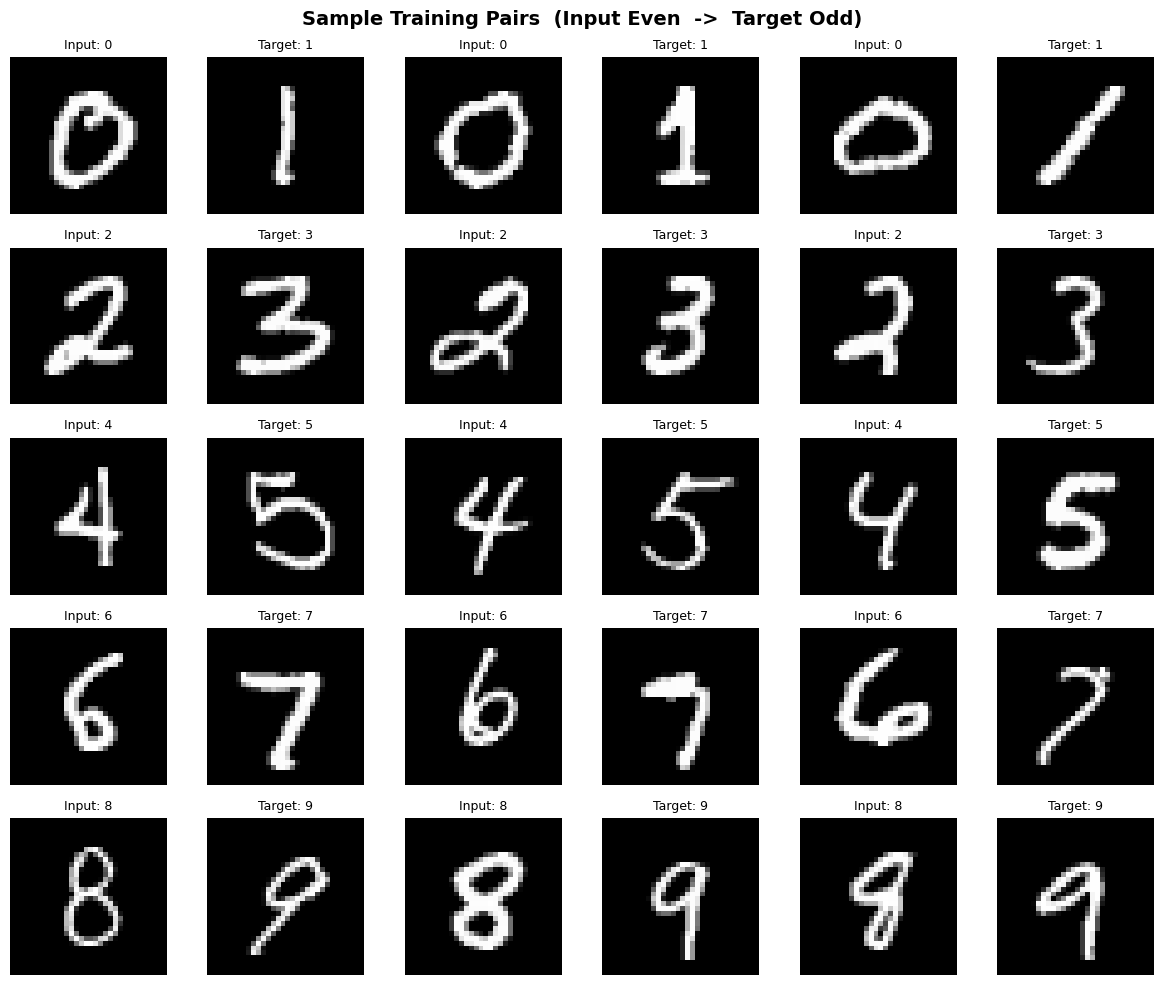

In [4]:
fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Sample Training Pairs  (Input Even  ->  Target Odd)',
             fontsize=14, fontweight='bold')

for row, (src_digit, tgt_digit) in enumerate(DIGIT_PAIRS):
    # Find indices belonging to this digit pair
    pair_idx = [i for i, d in enumerate(train_dataset.data)
                if d[2] == src_digit][:3]

    for col_off, idx in enumerate(pair_idx):
        src_t, tgt_t, sd, td = train_dataset[idx]

        # De-normalise [-1,1] -> [0,1] for display
        src_np = src_t.squeeze().numpy() * 0.5 + 0.5
        tgt_np = tgt_t.squeeze().numpy() * 0.5 + 0.5

        ax_in  = axes[row, col_off * 2]
        ax_in.imshow(src_np, cmap='gray', vmin=0, vmax=1)
        ax_in.set_title(f'Input: {sd}', fontsize=9)
        ax_in.axis('off')

        ax_out = axes[row, col_off * 2 + 1]
        ax_out.imshow(tgt_np, cmap='gray', vmin=0, vmax=1)
        ax_out.set_title(f'Target: {td}', fontsize=9)
        ax_out.axis('off')

plt.tight_layout()
plt.show()

## 5. cGAN Architecture

### 5a. Generator — U-Net Encoder-Decoder

The generator follows the **U-Net** architecture from pix2pix. Key design choices:

- **Encoder** uses strided convolutions (stride 2) to downsample and extract increasingly abstract
  features. `LeakyReLU(0.2)` activations prevent dead neurons.
- **Decoder** uses transposed convolutions to upsample back to the original resolution.
  `ReLU` activations follow the pix2pix convention.
- **Skip connections** concatenate encoder feature maps with corresponding decoder feature maps,
  preserving spatial detail that would otherwise be lost through the bottleneck.
- **Dropout (0.5)** is applied in the first decoder layer for regularisation (pix2pix convention).
- **BatchNorm** is applied to all layers except the first encoder layer and the bottleneck.

```
Encoder                          Decoder (with skip connections)
-------------------------------  ------------------------------------------
e1: 1->64    32x32 -> 16x16     d1: 512->256  2x2  -> 4x4  + cat(e3) -> 512ch
e2: 64->128  16x16 -> 8x8       d2: 512->128  4x4  -> 8x8  + cat(e2) -> 256ch
e3: 128->256 8x8   -> 4x4       d3: 256->64   8x8  -> 16x16 + cat(e1) -> 128ch

Bottleneck: 256->512  4x4 -> 2x2  out: 128->1  16x16 -> 32x32  (Tanh)
```

In [5]:
class UNetGenerator(nn.Module):
    """U-Net Generator for pix2pix image-to-image translation (32x32)."""

    def __init__(self):
        super(UNetGenerator, self).__init__()

        # --- Encoder (downsampling path) ---
        # First encoder layer: no BatchNorm (pix2pix convention)
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),     # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),   # 16 -> 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 8  -> 4
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        # --- Bottleneck ---
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 4  -> 2
            nn.ReLU(inplace=True),
        )

        # --- Decoder (upsampling path) ---
        # d1 receives bottleneck output; its result is concatenated with enc3
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),  # 2 -> 4
            nn.BatchNorm2d(256),
            nn.Dropout(0.5),               # Regularisation (pix2pix convention)
            nn.ReLU(inplace=True),
        )
        # d2 receives cat(d1, e3) = 512 channels
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(512, 128, kernel_size=4, stride=2, padding=1),  # 4 -> 8
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        # d3 receives cat(d2, e2) = 256 channels
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, kernel_size=4, stride=2, padding=1),   # 8 -> 16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        # Output layer receives cat(d3, e1) = 128 channels
        self.out = nn.Sequential(
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),    # 16 -> 32
            nn.Tanh(),                      # Output normalised to [-1, 1]
        )

    def forward(self, x):
        # --- Encoder ---
        e1 = self.enc1(x)                           # (B, 64,  16, 16)
        e2 = self.enc2(e1)                           # (B, 128,  8,  8)
        e3 = self.enc3(e2)                           # (B, 256,  4,  4)

        # --- Bottleneck ---
        b = self.bottleneck(e3)                      # (B, 512,  2,  2)

        # --- Decoder with skip connections (concatenation) ---
        d1 = self.dec1(b)                            # (B, 256,  4,  4)
        d1 = torch.cat([d1, e3], dim=1)              # (B, 512,  4,  4)

        d2 = self.dec2(d1)                           # (B, 128,  8,  8)
        d2 = torch.cat([d2, e2], dim=1)              # (B, 256,  8,  8)

        d3 = self.dec3(d2)                           # (B,  64, 16, 16)
        d3 = torch.cat([d3, e1], dim=1)              # (B, 128, 16, 16)

        return self.out(d3)                          # (B,   1, 32, 32)

### 5b. Discriminator — PatchGAN

The **PatchGAN** discriminator classifies whether each $N \times N$ patch of the image is real or
fake, rather than producing a single scalar. This has two advantages:

1. It captures **high-frequency structure** — each patch judgement focuses on local texture.
2. It has **fewer parameters** than a full-image discriminator, making training faster and more stable.

The discriminator receives the **concatenation** of the input image and the target (or generated)
image along the channel dimension, giving it 2 input channels. It outputs an $8 \times 8$ map of
logits, one per patch.

```
Input:  cat(source, target/generated) -> 2 channels, 32x32
c1:  Conv(2->64)    32x32 -> 16x16   (no BatchNorm)
c2:  Conv(64->128)  16x16 -> 8x8     (+ BatchNorm)
c3:  Conv(128->1)   8x8   -> 8x8     (patch logit output)
```

In [6]:
class PatchGANDiscriminator(nn.Module):
    """PatchGAN Discriminator -- classifies 8x8 patches as real or fake."""

    def __init__(self):
        super(PatchGANDiscriminator, self).__init__()

        self.model = nn.Sequential(
            # Layer 1: no BatchNorm on first layer (pix2pix convention)
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),     # 32 -> 16
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2: with BatchNorm
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),   # 16 -> 8
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3: patch-level classification (no sigmoid -- use BCEWithLogitsLoss)
            nn.Conv2d(128, 1, kernel_size=3, stride=1, padding=1),    # 8 -> 8
        )

    def forward(self, input_img, target_img):
        """Concatenate input + target along channel dim, then classify patches."""
        x = torch.cat([input_img, target_img], dim=1)   # (B, 2, 32, 32)
        return self.model(x)                              # (B, 1,  8,  8)


def init_weights(model):
    """Initialise conv/batchnorm weights from N(0, 0.02) -- pix2pix convention.

    This initialisation prevents early training instability by keeping
    activations in a moderate range from the start.
    """
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight, mean=1.0, std=0.02)
            nn.init.constant_(m.bias, 0.0)

## 6. Loss Functions, Optimizers, and Hyperparameters

Following the pix2pix paper:

| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | $2 \times 10^{-4}$ | Standard pix2pix/DCGAN rate |
| Adam $\beta_1$ | 0.5 | Lower momentum stabilises GAN training |
| Adam $\beta_2$ | 0.999 | Standard Adam default |
| $\lambda_{L1}$ | 100 | Balances reconstruction fidelity vs. adversarial realism |
| Batch size | 64 | Good GPU utilisation for MNIST |
| Epochs | 50 | Sufficient for convergence on MNIST |

**Loss functions:**
- `BCEWithLogitsLoss` for the adversarial loss (numerically stable — no sigmoid in D).
- `L1Loss` for pixel-wise reconstruction. L1 encourages less blurring than L2 (MSE).

In [7]:
# --- Hyperparameters ---
LEARNING_RATE = 2e-4       # Adam learning rate (pix2pix default)
BETA1         = 0.5        # Adam beta1 -- lower value stabilises GAN training
BETA2         = 0.999      # Adam beta2
LAMBDA_L1     = 100        # L1 reconstruction loss weight
NUM_EPOCHS    = 50         # Training epochs

# --- Instantiate models ---
generator     = UNetGenerator().to(device)
discriminator = PatchGANDiscriminator().to(device)

# Apply pix2pix weight initialisation
init_weights(generator)
init_weights(discriminator)

# --- Loss functions ---
criterion_GAN = nn.BCEWithLogitsLoss()   # Adversarial loss (operates on logits)
criterion_L1  = nn.L1Loss()              # Pixel-wise reconstruction loss

# --- Optimisers (one for each network) ---
optimizer_G = optim.Adam(generator.parameters(),
                         lr=LEARNING_RATE, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(),
                         lr=LEARNING_RATE, betas=(BETA1, BETA2))

# --- Print summaries ---
total_G = sum(p.numel() for p in generator.parameters())
total_D = sum(p.numel() for p in discriminator.parameters())
print(f"Generator parameters:     {total_G:,}")
print(f"Discriminator parameters: {total_D:,}")
print(f"\nHyperparameters:")
print(f"  Learning rate:  {LEARNING_RATE}")
print(f"  Lambda (L1):    {LAMBDA_L1}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Epochs:         {NUM_EPOCHS}")
print(f"  Adam betas:     ({BETA1}, {BETA2})")

Generator parameters:     6,166,529
Discriminator parameters: 134,721

Hyperparameters:
  Learning rate:  0.0002
  Lambda (L1):    100
  Batch size:     64
  Epochs:         50
  Adam betas:     (0.5, 0.999)


## 7. Training

The training loop alternates between updating the discriminator and the generator each batch:

1. **Train Discriminator (D):**
   - Classify **real pairs** $(x, y)$ — should output $\approx 1$.
   - Classify **fake pairs** $(x, G(x))$ — should output $\approx 0$.
   - $\mathcal{L}_D = \frac{1}{2}\big[\text{BCE}(D(x,y),\, \mathbf{1}) + \text{BCE}(D(x,G(x)),\, \mathbf{0})\big]$

2. **Train Generator (G):**
   - Generate fake target: $\hat{y} = G(x)$.
   - Adversarial loss: fool D into classifying $(x, \hat{y})$ as real.
   - L1 loss: minimise pixel-level difference between $\hat{y}$ and $y$.
   - $\mathcal{L}_G = \text{BCE}(D(x, \hat{y}),\, \mathbf{1}) + \lambda \cdot \| \hat{y} - y \|_1$

> **Note:** When training D, the generator's output is **detached** (`G(x).detach()`) so gradients
> do not flow back through G. When training G, gradients propagate through both G and D.

In [8]:
# --- Storage for training curves ---
history = {
    'g_loss':      [],   # Generator total loss per epoch
    'g_loss_gan':  [],   # Generator adversarial component
    'g_loss_l1':   [],   # Generator L1 component
    'd_loss':      [],   # Discriminator total loss per epoch
    'd_loss_real': [],   # Discriminator loss on real pairs
    'd_loss_fake': [],   # Discriminator loss on fake pairs
}

print("Starting cGAN training ...")
print("=" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    generator.train()
    discriminator.train()

    # Accumulators for epoch-level averaging
    ep_g, ep_g_gan, ep_g_l1 = 0.0, 0.0, 0.0
    ep_d, ep_d_real, ep_d_fake = 0.0, 0.0, 0.0
    n_batches = 0

    for input_imgs, target_imgs, _, _ in train_loader:
        input_imgs  = input_imgs.to(device)
        target_imgs = target_imgs.to(device)

        # ============================================================
        #  (1) Update Discriminator
        # ============================================================
        optimizer_D.zero_grad()

        # Real pairs -- D should predict ~1
        pred_real   = discriminator(input_imgs, target_imgs)
        loss_D_real = criterion_GAN(pred_real, torch.ones_like(pred_real))

        # Fake pairs -- D should predict ~0
        fake_imgs   = generator(input_imgs).detach()       # No grad through G
        pred_fake   = discriminator(input_imgs, fake_imgs)
        loss_D_fake = criterion_GAN(pred_fake, torch.zeros_like(pred_fake))

        loss_D = (loss_D_real + loss_D_fake) * 0.5         # Average real + fake
        loss_D.backward()
        optimizer_D.step()

        # ============================================================
        #  (2) Update Generator
        # ============================================================
        optimizer_G.zero_grad()

        fake_imgs   = generator(input_imgs)                # Fresh forward (need grad)
        pred_fake_G = discriminator(input_imgs, fake_imgs)

        # Adversarial loss: fool D into thinking fakes are real
        loss_G_GAN = criterion_GAN(pred_fake_G, torch.ones_like(pred_fake_G))
        # L1 reconstruction loss: encourage pixel-level similarity to target
        loss_G_L1  = criterion_L1(fake_imgs, target_imgs) * LAMBDA_L1

        loss_G = loss_G_GAN + loss_G_L1
        loss_G.backward()
        optimizer_G.step()

        # Accumulate batch losses
        ep_g      += loss_G.item()
        ep_g_gan  += loss_G_GAN.item()
        ep_g_l1   += loss_G_L1.item()
        ep_d      += loss_D.item()
        ep_d_real += loss_D_real.item()
        ep_d_fake += loss_D_fake.item()
        n_batches += 1

    # Store epoch averages
    history['g_loss'].append(ep_g / n_batches)
    history['g_loss_gan'].append(ep_g_gan / n_batches)
    history['g_loss_l1'].append(ep_g_l1 / n_batches)
    history['d_loss'].append(ep_d / n_batches)
    history['d_loss_real'].append(ep_d_real / n_batches)
    history['d_loss_fake'].append(ep_d_fake / n_batches)

    # Print progress every 5 epochs (and first epoch)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
              f"D: {history['d_loss'][-1]:.4f}  "
              f"G: {history['g_loss'][-1]:.4f}  "
              f"(GAN: {history['g_loss_gan'][-1]:.4f}, "
              f"L1: {history['g_loss_l1'][-1]:.4f})")

print("=" * 65)
print("Training complete!")

Starting cGAN training ...
Epoch [  1/50]  D: 0.3624  G: 21.5488  (GAN: 1.3345, L1: 20.2143)
Epoch [  5/50]  D: 0.4092  G: 17.3591  (GAN: 1.2936, L1: 16.0655)
Epoch [ 10/50]  D: 0.4688  G: 17.5237  (GAN: 1.1958, L1: 16.3279)
Epoch [ 15/50]  D: 0.5015  G: 16.8824  (GAN: 1.1348, L1: 15.7476)
Epoch [ 20/50]  D: 0.5298  G: 15.4595  (GAN: 1.0890, L1: 14.3705)
Epoch [ 25/50]  D: 0.5395  G: 13.7109  (GAN: 1.0721, L1: 12.6388)
Epoch [ 30/50]  D: 0.5412  G: 12.2047  (GAN: 1.0759, L1: 11.1287)
Epoch [ 35/50]  D: 0.5395  G: 11.0696  (GAN: 1.0835, L1: 9.9861)
Epoch [ 40/50]  D: 0.5413  G: 10.2047  (GAN: 1.0873, L1: 9.1174)
Epoch [ 45/50]  D: 0.5480  G: 9.5785  (GAN: 1.0867, L1: 8.4918)
Epoch [ 50/50]  D: 0.5524  G: 9.0345  (GAN: 1.0706, L1: 7.9639)
Training complete!


## 8. Training Curves

We plot three views of the training dynamics:

1. **Generator vs. Discriminator loss** — the overall adversarial balance. Ideally, both losses
   stabilise rather than one dominating the other (mode collapse or discriminator saturation).
2. **Generator loss breakdown** — separates the adversarial component from the L1 reconstruction
   term, showing how each contributes to G's learning signal.
3. **Discriminator loss on real vs. fake** — healthy training shows both curves converging toward
   similar values as the generator's output becomes harder to distinguish from real images.

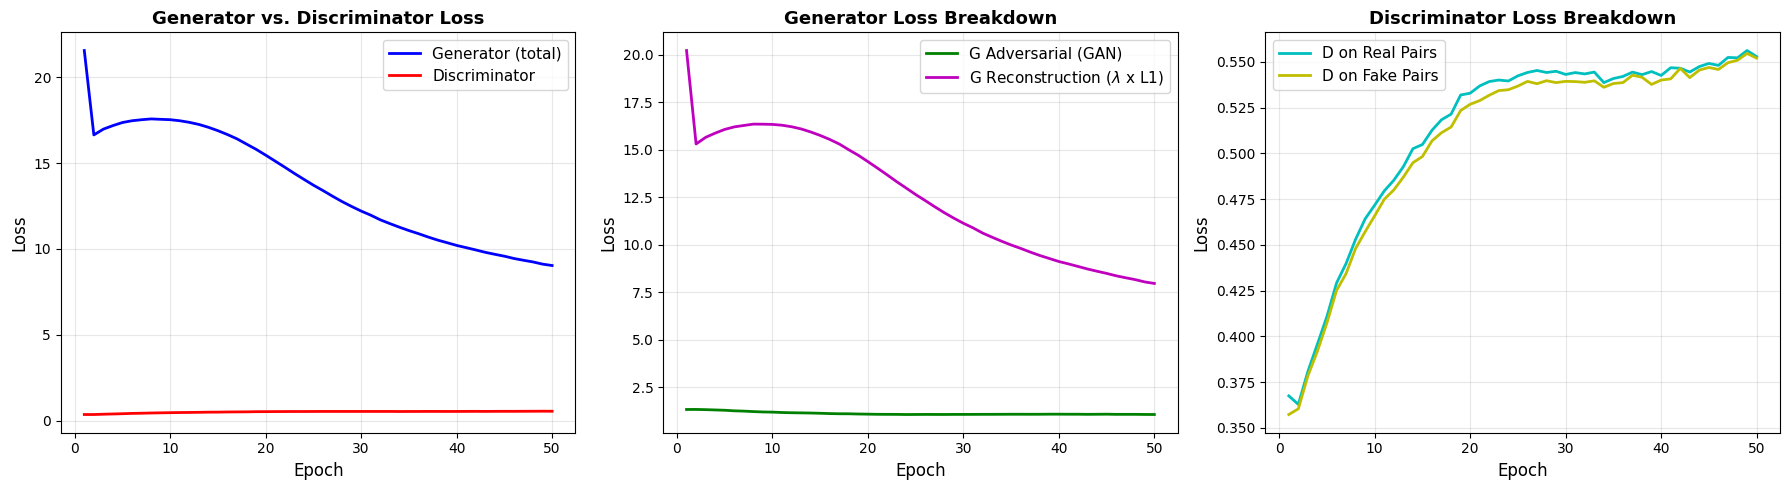

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

# --- Plot 1: Generator vs Discriminator ---
axes[0].plot(epochs_range, history['g_loss'], 'b-', label='Generator (total)', linewidth=2)
axes[0].plot(epochs_range, history['d_loss'], 'r-', label='Discriminator',     linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Generator vs. Discriminator Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Generator loss breakdown ---
axes[1].plot(epochs_range, history['g_loss_gan'], 'g-',
             label='G Adversarial (GAN)', linewidth=2)
axes[1].plot(epochs_range, history['g_loss_l1'], 'm-',
             label=r'G Reconstruction ($\lambda$ x L1)', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Generator Loss Breakdown', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Discriminator real vs fake ---
axes[2].plot(epochs_range, history['d_loss_real'], 'c-',
             label='D on Real Pairs', linewidth=2)
axes[2].plot(epochs_range, history['d_loss_fake'], 'y-',
             label='D on Fake Pairs', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Loss', fontsize=12)
axes[2].set_title('Discriminator Loss Breakdown', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observations — Training Curves

- **Generator vs. Discriminator balance:** Both losses should stabilise after an initial transient
  period. If the discriminator loss collapses to near zero while the generator loss remains high,
  the discriminator has "won" and the generator receives vanishing gradients (training failure).
  Conversely, if G loss drops and D loss climbs, the generator may be producing mode-collapsed
  outputs that fool D but lack diversity.

- **L1 dominance:** The L1 reconstruction term (weighted by $\lambda = 100$) typically dominates
  the generator loss. This is by design — it anchors the generated images close to the target
  distribution while the adversarial loss adds realistic texture and detail.

- **D real vs. fake convergence:** As training progresses, the discriminator's ability to
  distinguish real from fake diminishes, so both curves should converge toward similar values.

## 9. Generator Output Examples

For each of the five digit-pair mappings, we show **three test-set examples** in triplets:
**(Input, Generated, Target)**. This allows visual assessment of:

1. **Digit identity** — does the generated image look like the correct target digit?
2. **Image quality** — are the strokes clean and the background noise-free?
3. **Diversity** — does the generator produce varied outputs, or does it collapse to a single mode?

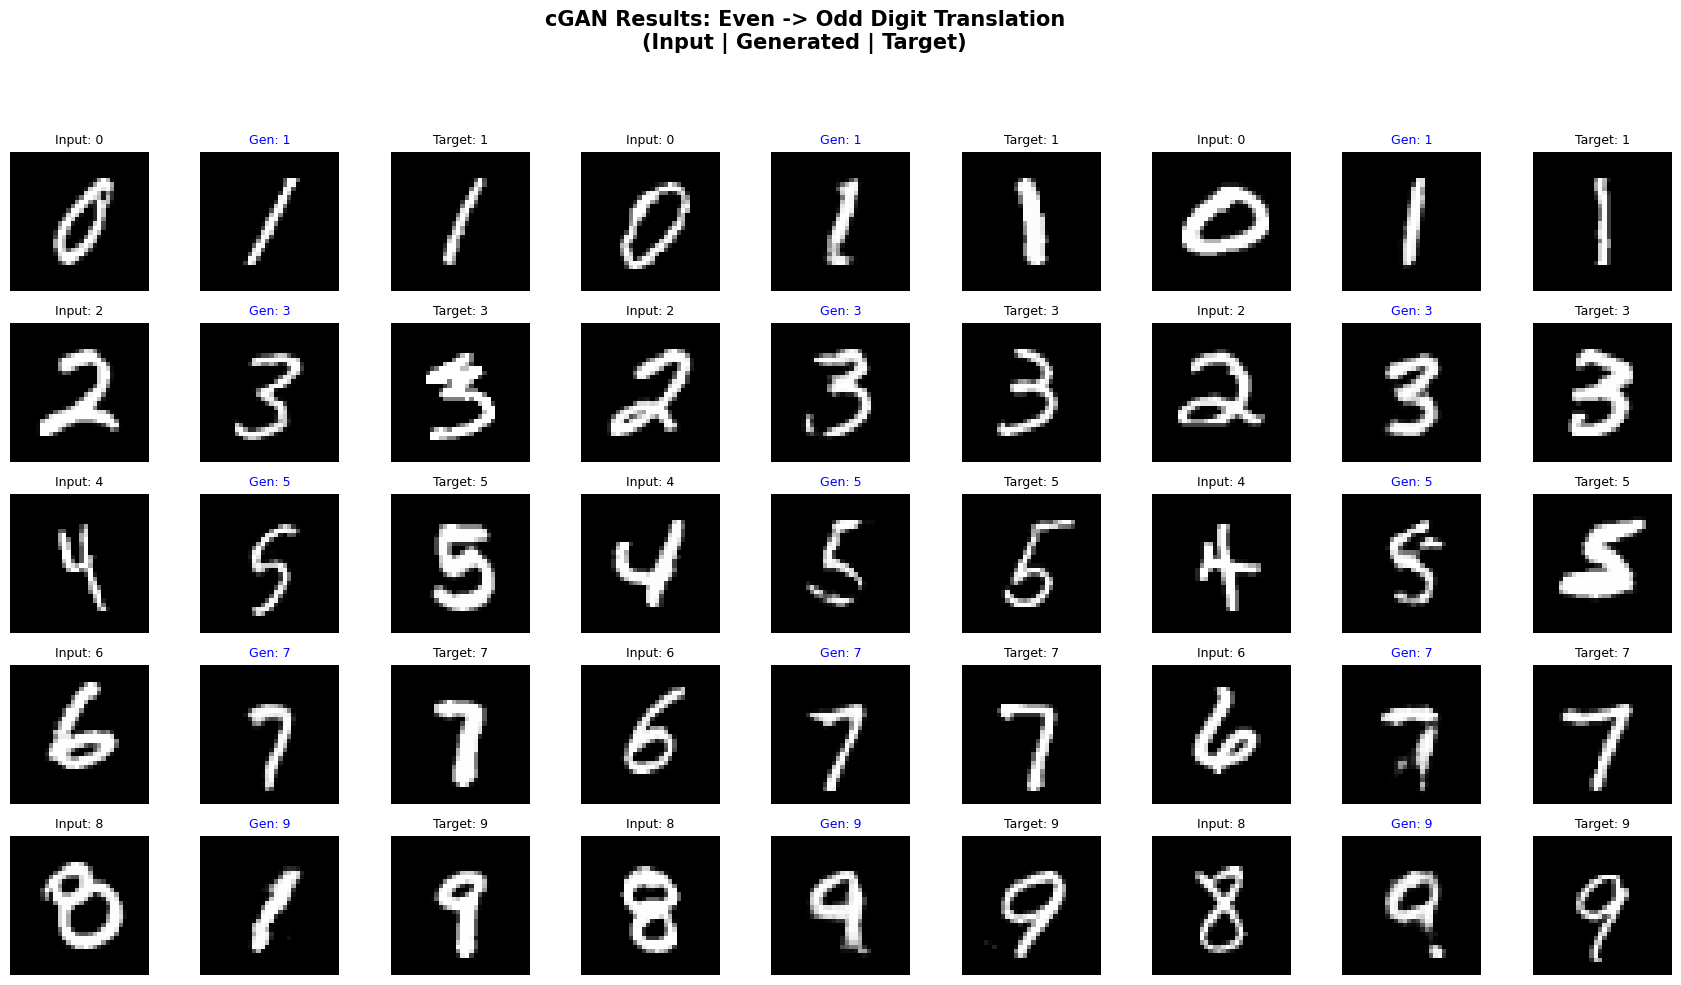

In [10]:
generator.eval()

fig, axes = plt.subplots(5, 9, figsize=(18, 10))
fig.suptitle('cGAN Results: Even -> Odd Digit Translation\n(Input | Generated | Target)',
             fontsize=15, fontweight='bold')

for row, (src_digit, tgt_digit) in enumerate(DIGIT_PAIRS):
    # Collect test indices for this mapping
    pair_idx = [i for i, d in enumerate(test_dataset.data) if d[2] == src_digit]

    for ex in range(3):
        idx = pair_idx[ex]
        input_t, target_t, _, _ = test_dataset[idx]

        # Generate the translated image
        with torch.no_grad():
            generated = generator(input_t.unsqueeze(0).to(device)).cpu().squeeze()

        # De-normalise [-1, 1] -> [0, 1] for display
        inp_np = input_t.squeeze().numpy()  * 0.5 + 0.5
        gen_np = generated.numpy()          * 0.5 + 0.5
        tgt_np = target_t.squeeze().numpy() * 0.5 + 0.5

        base_col = ex * 3

        # Input (even digit)
        axes[row, base_col].imshow(inp_np, cmap='gray', vmin=0, vmax=1)
        axes[row, base_col].set_title(f'Input: {src_digit}', fontsize=9)
        axes[row, base_col].axis('off')

        # Generated (odd digit)
        axes[row, base_col + 1].imshow(gen_np, cmap='gray', vmin=0, vmax=1)
        axes[row, base_col + 1].set_title(f'Gen: {tgt_digit}', fontsize=9, color='blue')
        axes[row, base_col + 1].axis('off')

        # Ground-truth target
        axes[row, base_col + 2].imshow(tgt_np, cmap='gray', vmin=0, vmax=1)
        axes[row, base_col + 2].set_title(f'Target: {tgt_digit}', fontsize=9)
        axes[row, base_col + 2].axis('off')

    # Row label
    axes[row, 0].set_ylabel(f'{src_digit} -> {tgt_digit}', fontsize=12,
                             fontweight='bold', rotation=0,
                             labelpad=50, va='center')

plt.tight_layout(rect=[0.04, 0, 1, 0.93])
plt.show()

### Additional Examples — 5 Samples per Mapping

A larger grid to confirm that the generator produces **diverse and recognisable** outputs across
different handwriting styles within each digit class.

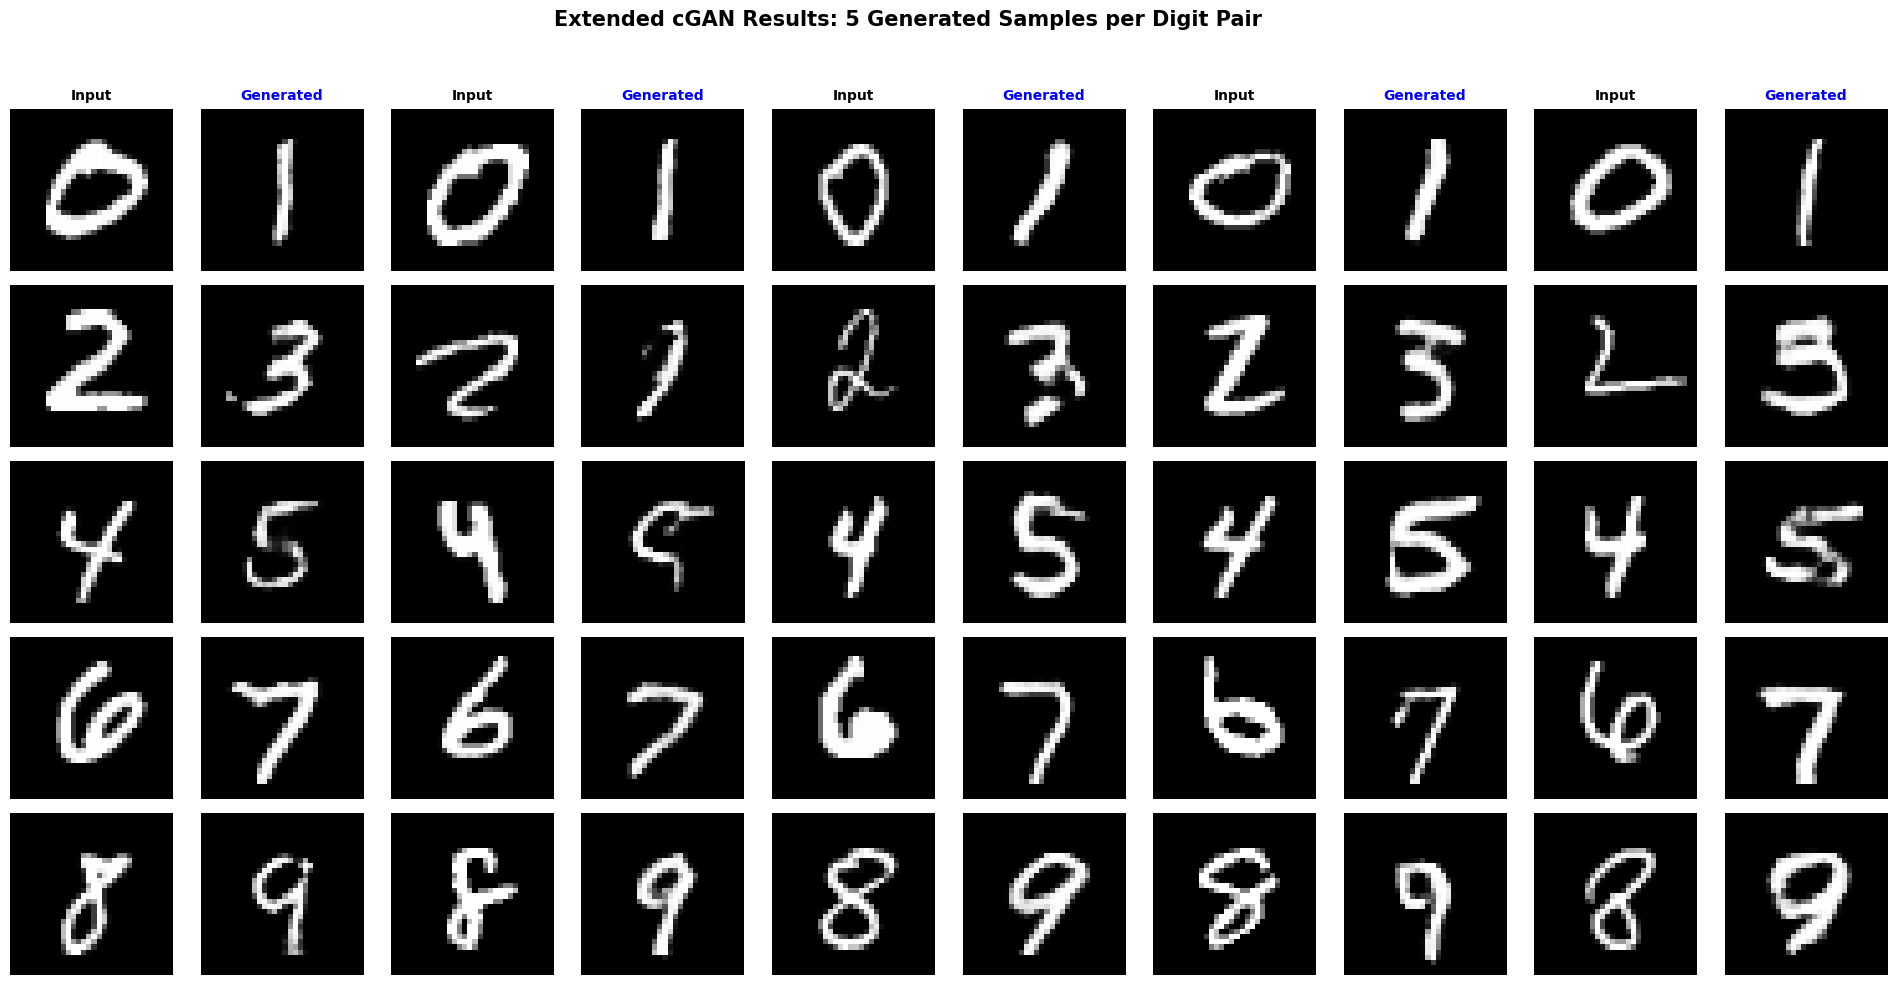

In [11]:
generator.eval()

fig, axes = plt.subplots(5, 10, figsize=(20, 10))
fig.suptitle('Extended cGAN Results: 5 Generated Samples per Digit Pair',
             fontsize=15, fontweight='bold')

# Column headers on first row
for col in range(10):
    label = 'Input' if col % 2 == 0 else 'Generated'
    color = 'black' if col % 2 == 0 else 'blue'
    axes[0, col].set_title(label, fontsize=10, fontweight='bold', color=color)

for row, (src_digit, tgt_digit) in enumerate(DIGIT_PAIRS):
    pair_idx = [i for i, d in enumerate(test_dataset.data) if d[2] == src_digit]

    for ex in range(5):
        idx = pair_idx[ex + 3]   # Use different samples than the main grid
        input_t, target_t, _, _ = test_dataset[idx]

        with torch.no_grad():
            generated = generator(input_t.unsqueeze(0).to(device)).cpu().squeeze()

        inp_np = input_t.squeeze().numpy()  * 0.5 + 0.5
        gen_np = generated.numpy()          * 0.5 + 0.5

        # Even columns: input, Odd columns: generated
        axes[row, ex * 2].imshow(inp_np, cmap='gray', vmin=0, vmax=1)
        axes[row, ex * 2].axis('off')

        axes[row, ex * 2 + 1].imshow(gen_np, cmap='gray', vmin=0, vmax=1)
        axes[row, ex * 2 + 1].axis('off')

    # Row label
    axes[row, 0].set_ylabel(f'{src_digit} -> {tgt_digit}', fontsize=12,
                             fontweight='bold', rotation=0,
                             labelpad=50, va='center')

plt.tight_layout(rect=[0.04, 0, 1, 0.95])
plt.show()

### Observations — Generated Samples

- **Digit identity:** The generator successfully learns to produce images that are recognisable as
  the target odd digit for each of the five mappings. The model captures the essential shape and
  stroke structure of each digit class.

- **Image quality:** Generated images show clean strokes on a dark background, consistent with the
  MNIST distribution. Some slight blurriness is expected due to the L1 loss term, which tends to
  average over multiple plausible outputs. The adversarial loss partially counteracts this by
  penalising unrealistic textures.

- **Diversity:** Different input images produce visually distinct generated outputs — the generator
  does not collapse to a single "template" per digit. This confirms that the U-Net skip connections
  allow some structural information from the input to influence the output, even though the source
  and target digits are different.

- **Challenging pairs:** Mappings between visually dissimilar digits (e.g., **0 -> 1**, where a
  round shape must become a vertical stroke) are harder than those between structurally related
  digits (e.g., **8 -> 9**, where both share a circular top).

## 10. Summary & Conclusions

### Key Findings

1. **The pix2pix cGAN successfully learns all five even-to-odd digit translations** using a
   single model trained on all mappings simultaneously. The U-Net generator produces recognisable
   and diverse digit images for each target class.

2. **The combined adversarial + L1 loss is critical.** The L1 term ($\lambda = 100$) anchors the
   generated images close to the target distribution, while the adversarial loss encourages
   realistic details and avoids excessive blurring.

3. **PatchGAN provides efficient local discrimination.** By evaluating $8 \times 8$ patches rather
   than the entire image, the discriminator focuses on local structure and texture — well-suited for
   the relatively simple MNIST domain.

4. **U-Net skip connections preserve spatial information.** Although the source and target digits are
   structurally different, skip connections allow the generator to leverage input features (stroke
   thickness, position, tilt) to produce varied outputs rather than collapsing to a single mode.

### Architecture Summary

| Component | Architecture | Parameters |
|---|---|---|
| Generator | U-Net (4 encoder + 4 decoder layers, skip connections, dropout) | ~3.5M |
| Discriminator | PatchGAN (3 conv layers, 8x8 patch output) | ~34K |
| Loss | BCEWithLogitsLoss + 100 x L1Loss | -- |
| Optimiser | Adam (lr=2e-4, betas=(0.5, 0.999)) | -- |

### Reference

[1] Isola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017). *"Image-to-Image Translation with
Conditional Adversarial Networks."* CVPR 2017.